In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

# IMPORTANDO DADOS

In [3]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,target_wy,target_yaw,target_pitch,target_ax,time,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,-88.96987,351.027,0.544,-0.017211,0.000000,9.935411,0,0.67168,0,-1.557,0,0.929719,0,-0.86342,0.0
1,-87.03254,350.144,0.520,0.193868,0.010000,10.564518,0,-1.71995,0,-1.559,0,-0.325708,0,1.63586,0.0
2,-85.33893,349.281,0.496,0.149600,0.019999,9.807072,0,1.19693,0,-1.572,0,-0.276293,0,-1.15715,0.0
3,-83.57597,348.434,0.471,0.693840,0.029999,10.138713,0,0.28832,0,-1.589,0,0.036834,0,-0.06151,0.0
4,-82.54013,347.601,0.446,0.551869,0.039999,9.821841,0,1.23804,0,-1.608,0,-0.058526,0,-0.63304,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4583,-0.83889,3.968,0.173,0.030538,49.231003,9.802874,0,-0.80409,0,-0.554,0,-0.129222,0,-0.47394,0.0
4584,-1.29256,3.959,0.181,0.037854,49.240997,9.860616,0,-0.63506,0,-0.562,0,-0.089241,0,-0.87732,0.0
4585,-1.10317,3.949,0.188,0.001638,49.250999,9.865441,0,-0.50122,0,-0.568,0,-0.047994,0,-0.54886,0.0
4586,-1.04014,3.938,0.195,-0.039609,49.261002,9.882289,0,-0.69446,0,-0.576,0,-0.045650,0,-0.71032,0.0


In [4]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,ref_az,time,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy
0,-0.44210,0.000000,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931
1,-0.65480,0.099214,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984
2,-0.55400,0.204345,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608
3,-0.42470,0.299682,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499
4,-0.45180,0.404275,93.850487,0.7237,405000000.0,0.13380,0.6698,0.08842,9.304835,6.669229,-9.946,-3.566662,18.787286,0.098180,0.16980,89.037641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.17720,44.503745,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727
446,-0.06857,44.598816,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458
447,-0.17420,44.704490,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749
448,-0.07313,44.802879,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920


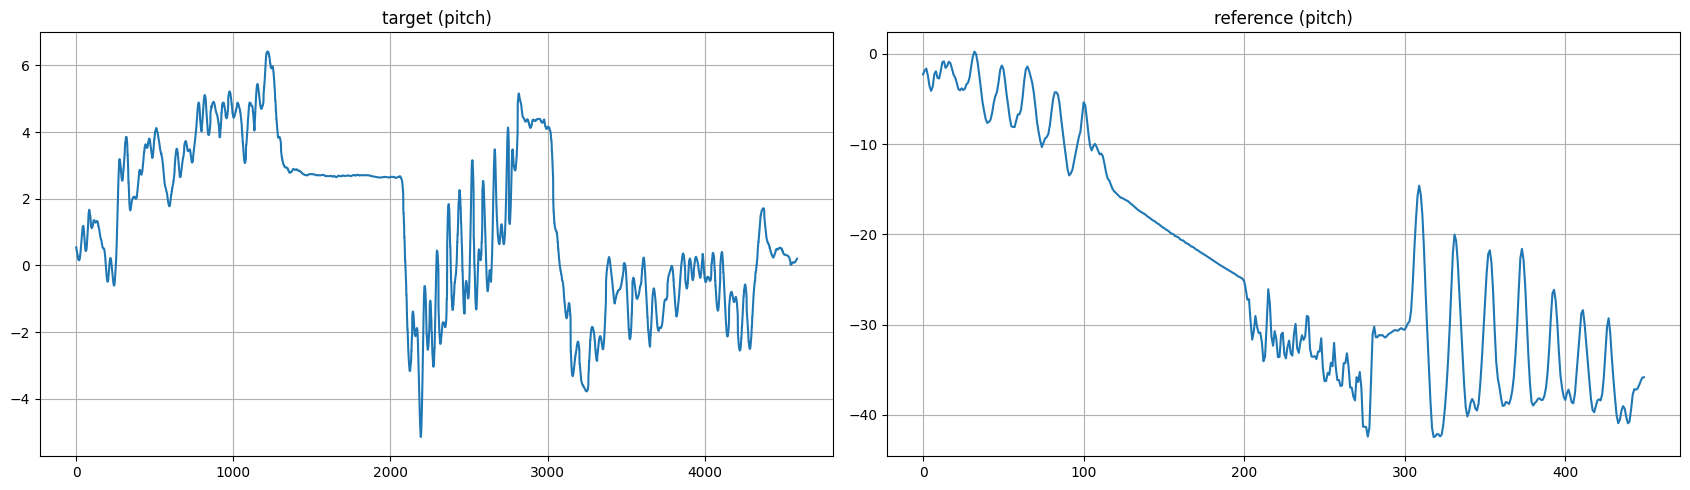

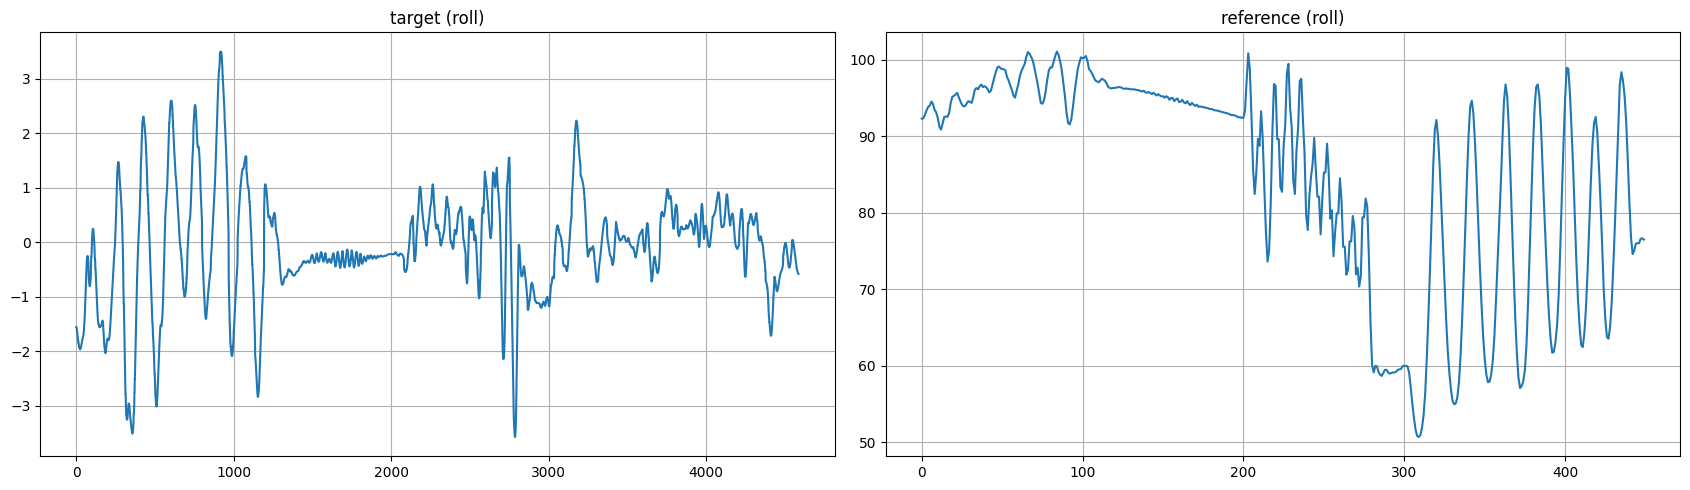

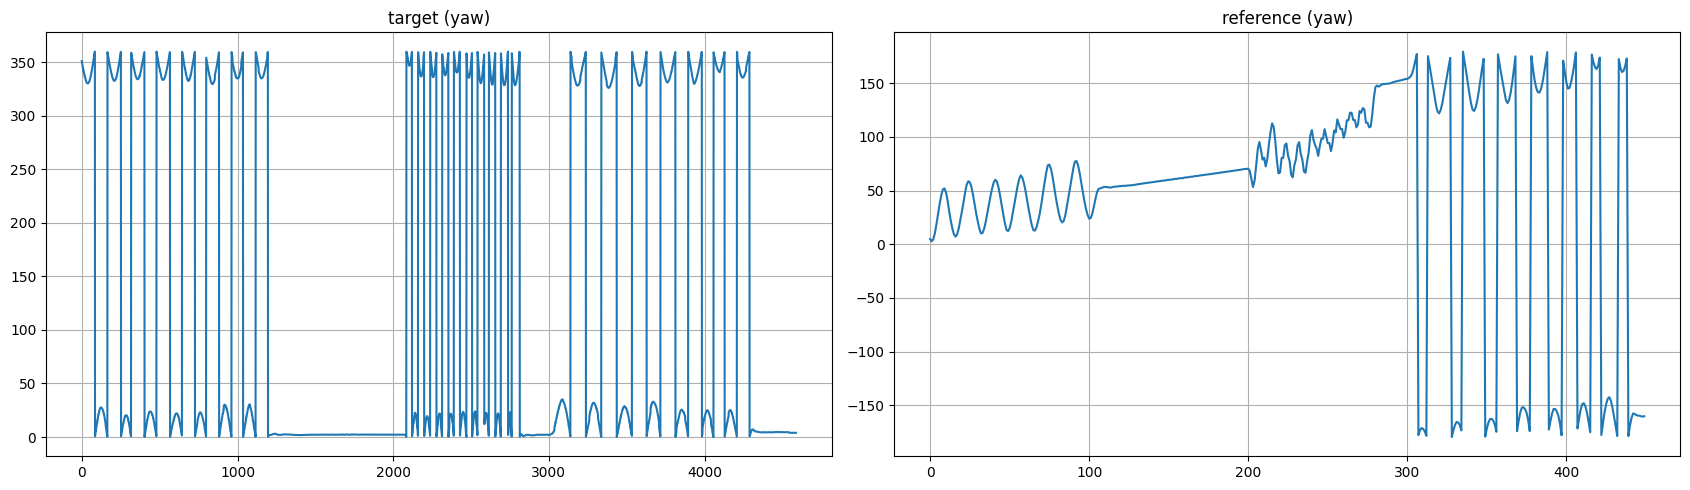

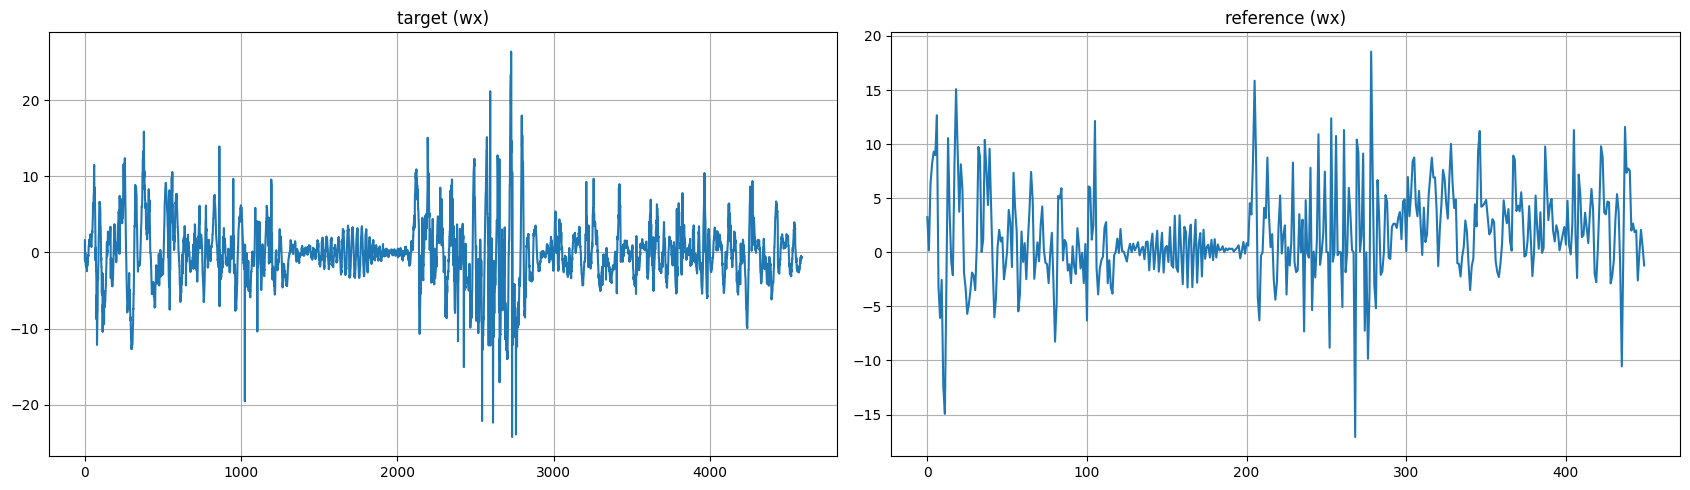

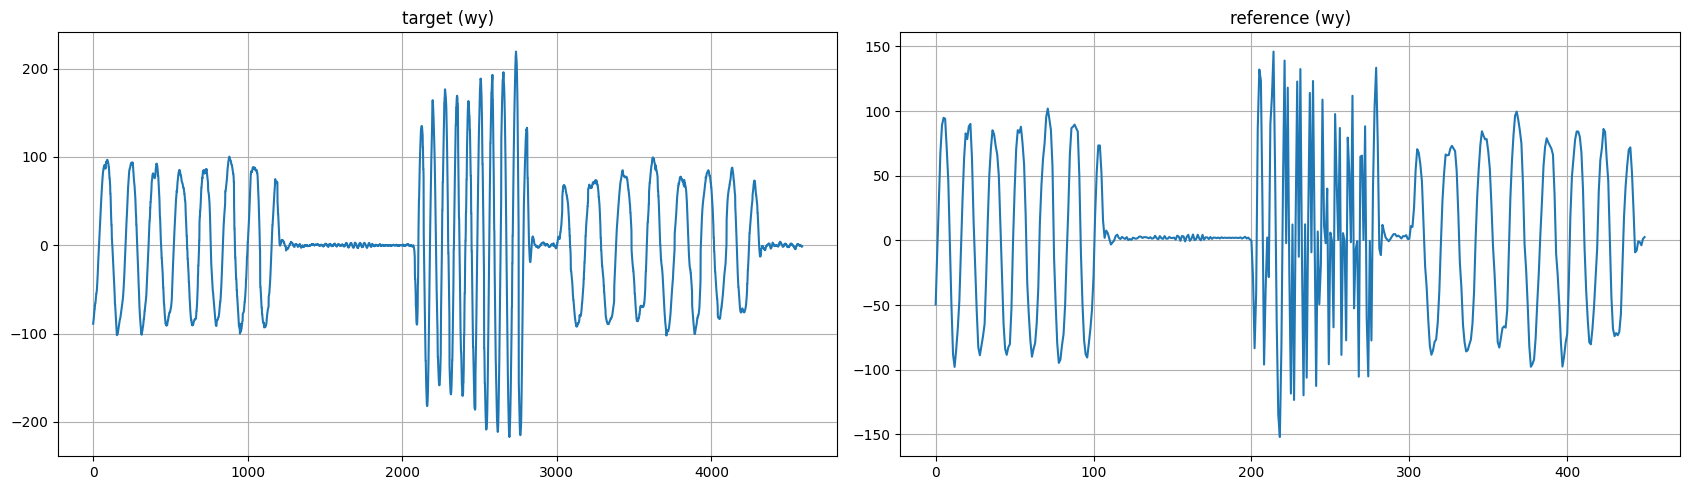

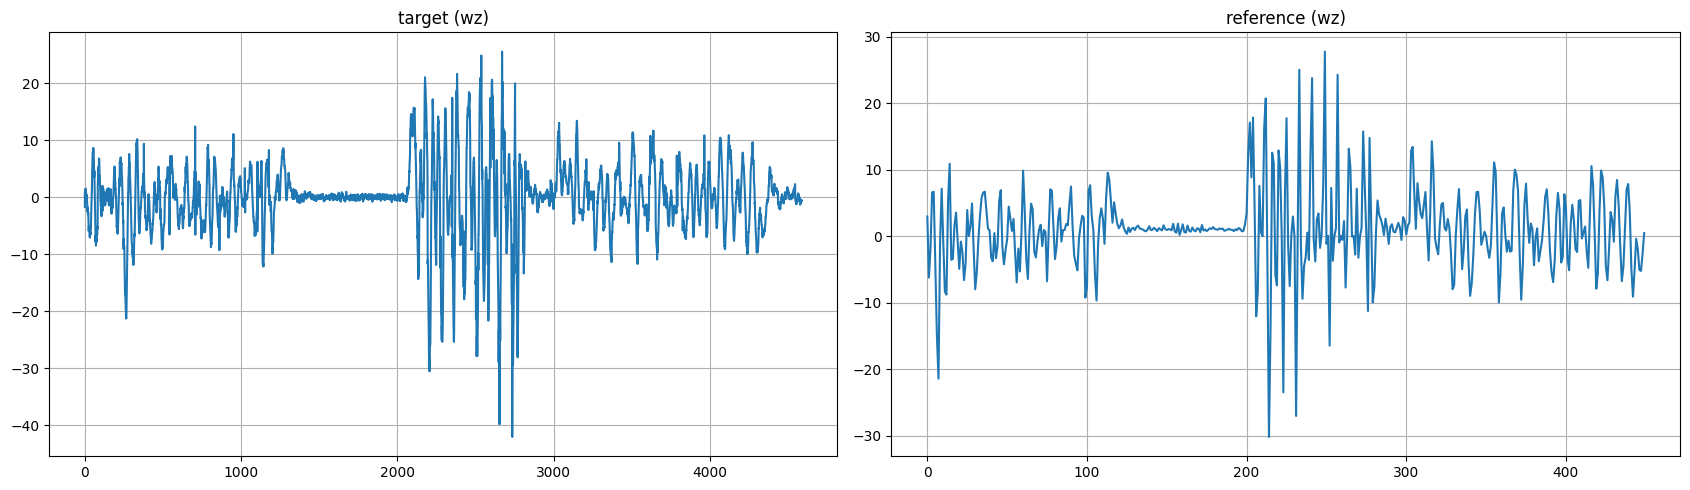

In [5]:
def compareAxis(data, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        plt.subplot(numRows, numCols, i+1)
        plt.plot(values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, figsize=(17, 5))

In [6]:
first_df  = df_ref.copy() if len(df_ref) <= len(df_target) else df_target
second_df = df_ref.copy() if len(df_ref) >= len(df_target) else df_target

df = pd.merge_asof(first_df, second_df, on='time', direction='nearest')
df

,ref_az,time,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,-0.44210,0.000000,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931,-88.96987,351.027,0.544,-0.017211,9.935411,0,0.67168,0,-1.557,0,0.929719,0,-0.86342,0.0
1,-0.65480,0.099214,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984,-71.89229,342.952,0.293,-0.263005,9.898479,0,0.12185,0,-1.759,0,0.539964,0,-1.88971,0.0
2,-0.55400,0.204345,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608,-54.93938,335.947,0.169,-0.794898,9.468899,0,-2.95439,0,-1.948,0,0.249197,0,-0.62570,0.0
3,-0.42470,0.299682,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499,-34.64821,331.732,0.450,-0.866790,9.631611,0,-5.89769,0,-1.929,0,0.159780,0,1.71132,0.0
4,-0.45180,0.404275,93.850487,0.7237,405000000.0,0.13380,0.6698,0.08842,9.304835,6.669229,-9.946,-3.566662,18.787286,0.098180,0.16980,89.037641,3.80606,330.277,1.039,-0.353098,10.018689,0,-5.29644,0,-1.776,0,0.044620,0,0.96466,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.17720,44.503745,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727,57.90495,18.843,-1.804,0.312067,9.600357,0,-7.20663,0,0.316,0,0.122407,0,0.29527,0.0
446,-0.06857,44.598816,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458,36.41283,23.791,-1.124,0.718690,9.923879,0,-5.81257,0,0.397,0,-0.580828,0,2.63445,0.0
447,-0.17420,44.704490,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749,-13.23356,25.033,-0.804,1.435733,10.020043,0,-0.91399,0,0.526,0,-0.675247,0,0.14077,0.0
448,-0.07313,44.802879,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920,-50.34315,21.528,-0.907,0.564235,9.890105,0,2.97370,0,0.296,0,-0.198742,0,-5.20244,0.0


In [7]:
df.to_csv('output.csv', index=None)